# 02 · Prediction becomes a decision through losses

## Goal
Work with supplied probabilities. These are invented fixtures, not Jev outputs.

**Status:** worked example prepared by Codex; learner understanding unassessed. No API calls.

## Setup
Run top to bottom. All examples are synthetic unless explicitly labelled as public evidence.

In [1]:
from pathlib import Path
import sys, json, tempfile
ROOT = Path.cwd()
if ROOT.name == 'notebooks': ROOT = ROOT.parent
assert (ROOT / 'signal_lab').is_dir(), 'Run from the companion root or notebooks directory'
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({'figure.figsize': (8, 4.2), 'font.size': 11, 'axes.spines.top': False, 'axes.spines.right': False})


## Steps

### 1. Inspect routes and consequences

In [2]:
from signal_lab.decisions import routing_fixture, choose_action, brier, rule_route
rows=[{'truth':x['truth'], 'rule':rule_route(x['question']), **choose_action(x['p']), 'Brier':brier(x['p'],x['truth'])} for x in routing_fixture()]
pd.DataFrame(rows).round(3)

,truth,rule,action,predicted_route,automatic_expected_loss,chosen_expected_loss,Brier
0,both,both,review,both,1.4,1.0,0.007
1,documents,documents,documents,documents,0.4,0.4,0.001
2,clarify,clarify,review,data,5.0,1.0,1.385
3,data,data,data,data,0.6,0.6,0.001


### 2. Derive the threshold
For symmetric wrong-route cost 20 and perfect review cost 1, accept when `20(1−p) < 1`. Equality goes to review. The model probability must be meaningful for this decision; this plot does not establish calibration.

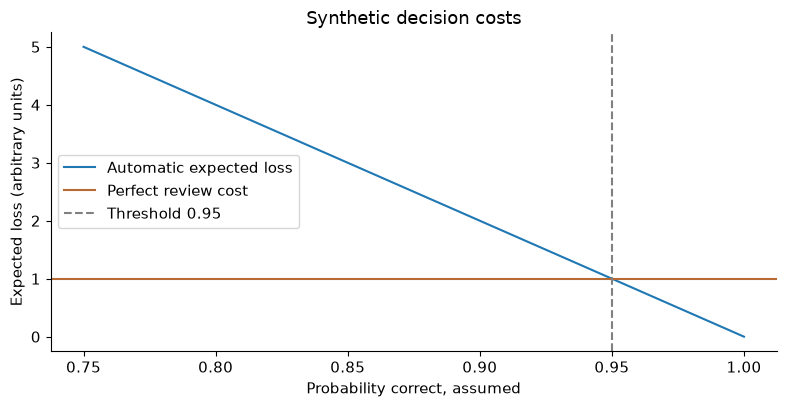

In [3]:
p=np.linspace(.75,1,101)
plt.plot(p,20*(1-p),label='Automatic expected loss')
plt.axhline(1,color='#b86a35',label='Perfect review cost')
plt.axvline(.95,color='gray',linestyle='--',label='Threshold 0.95')
plt.xlabel('Probability correct, assumed'); plt.ylabel('Expected loss (arbitrary units)')
plt.title('Synthetic decision costs');plt.legend();plt.tight_layout();plt.show()

## Checks
Inspect the confidently wrong ambiguous-question fixture. Four invented cases do not support a calibration conclusion.

## Next Steps
Optional: make review cost 2 and derive the new threshold before plotting. OpenRouter later supplies alternative models for the same interface; Jev availability is separate.

**Low energy:** stop here. The checkpoint is optional; reading the worked output does not update mastery.